# Notebook 2 — Build the flood mask

**Goal:** turn the two radar images from Notebook 1 into a single map that says, for every pixel, *"was this flooded in July 2023 or not?"*

The idea in one line: **water makes radar go dark, so pixels that got much darker between June and July are our flood.**

Output: `data/outputs/flood_mask.tif` — a 1 = flooded / 0 = dry map.

## Step 1 — Load the two GeoTIFFs

A **GeoTIFF** is just an image where every pixel also knows its real-world location (its longitude/latitude). We open ours with `rasterio`.

Both files came from the same Earth Engine request, so they already share the **exact same grid** (same size, same pixel locations, same CRS = EPSG:4326). That's lucky — it means we can subtract one from the other pixel-by-pixel without any alignment work.

One catch: the edges of the images contain **nodata** pixels, stored as `-inf` (negative infinity). If we leave those in, they'll wreck the maths — so we convert them to `NaN` ("not a number", i.e. *blank*) and keep track of which pixels are valid.

In [2]:
import numpy as np
import rasterio
from scipy.ndimage import uniform_filter, binary_opening
import matplotlib.pyplot as plt
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = REPO / "data" / "raw"
OUT = REPO / "data" / "outputs"
OUT.mkdir(parents=True, exist_ok=True)

with rasterio.open(RAW / "s1_vv_pre.tif") as src:
    pre = src.read(1).astype("float32")
    profile = src.profile          # we reuse this to save our output with the same georeferencing
    transform = src.transform
with rasterio.open(RAW / "s1_vv_post.tif") as src:
    post = src.read(1).astype("float32")

# Mark valid pixels and blank out the -inf nodata edges
valid = np.isfinite(pre) & np.isfinite(post)
pre[~valid] = np.nan
post[~valid] = np.nan

print("Image size:", pre.shape)
print("Valid pixels:", int(valid.sum()))
print("Pre  dB range:", round(float(np.nanmin(pre)), 1), "to", round(float(np.nanmax(pre)), 1))
print("Post dB range:", round(float(np.nanmin(post)), 1), "to", round(float(np.nanmax(post)), 1))

Image size: (3118, 2228)
Valid pixels: 6946904
Pre  dB range: -32.1 to 29.1
Post dB range: -37.9 to 29.8


## Step 2 — Calm the speckle (Lee filter)

Radar images have a grainy, salt-and-pepper texture called **speckle**. It comes from the physics of radar (waves bouncing off rough surfaces interfere with each other) and it makes pixel-by-pixel comparison noisy.

The classic fix is a **Lee filter**. Think of it as a *smart blur*: in smooth areas (like water) it averages strongly to kill noise, but near edges (like a riverbank) it averages gently so it doesn't smear the boundary. We build it from a simple moving-average (`uniform_filter`) plus the local variance.

In [3]:
def lee_filter(img, size=7):
    """Lee speckle filter. Smooths flat areas hard, edges gently."""
    m = img.copy()
    m[np.isnan(m)] = np.nanmean(m)          # temporarily fill blanks so the filter doesn't spread them
    local_mean = uniform_filter(m, size)
    local_sqr_mean = uniform_filter(m * m, size)
    local_var = local_sqr_mean - local_mean ** 2
    overall_var = np.nanvar(m)
    weight = local_var / (local_var + overall_var)
    out = local_mean + weight * (m - local_mean)
    out[~valid] = np.nan                      # restore the blanks
    return out

pre_f = lee_filter(pre)
post_f = lee_filter(post)
print("Speckle filter applied to both images.")

Speckle filter applied to both images.


## Step 3 — Change detection (the actual flood signal)

Now the key step. We subtract the *before* image from the *after* image:

```
diff = post - pre
```

Because water is dark to radar, a pixel that flooded will have a **lower** (more negative) value after, so its `diff` is **negative**. The more negative the drop, the more confident we are it's water.

- `diff` near 0  → nothing changed (dry land that stayed dry)
- `diff` strongly negative → got much darker → **newly flooded**

In [5]:
diff = post_f - pre_f
print("Difference computed. Negative values = backscatter dropped = candidate flood.")

Difference computed. Negative values = backscatter dropped = candidate flood.


## Step 4 — Threshold into a yes/no flood mask

We turn the continuous `diff` into a clean **1 = flood / 0 = dry** map with three rules:

1. **Threshold:** keep pixels where the backscatter dropped by at least **3 dB** (`diff < -3`). A 3 dB drop is a roughly 2× fall in radar brightness — a strong, reliable water signal. (We checked this value against the data; feel free to try -2.5 or -4 and re-run.)
2. **Remove permanent water:** the Yamuna's main channel was already water *before* the flood, so it isn't *new* flooding. We flag pixels that were already dark before (`pre < -18 dB`) and exclude them. *(A more rigorous project would use the JRC Global Surface Water layer here — a good future upgrade.)*
3. **Clean up specks:** a single isolated "flood" pixel is almost always leftover noise. `binary_opening` erases tiny blobs while keeping the real, connected flood areas.

Finally we convert the pixel count into an area in km².

In [6]:
THRESHOLD_DB = -3.0     # how big a darkening counts as flood
PERM_WATER_DB = -18.0   # pixels already this dark before the flood = permanent water

perm_water = pre_f < PERM_WATER_DB
flood = (diff < THRESHOLD_DB) & valid & (~perm_water)
flood = binary_opening(flood, iterations=1)   # remove single-pixel noise

# Area per pixel (the grid is in degrees, so convert using the local latitude)
lat_mid = transform.f + transform.e * (pre.shape[0] / 2)
px_km2 = (abs(transform.a) * 111.32 * np.cos(np.deg2rad(lat_mid))) * (abs(transform.e) * 111.32)
flood_km2 = int(flood.sum()) * px_km2

print(f"Flooded pixels: {int(flood.sum()):,}")
print(f"Flooded area:   {flood_km2:.1f} km²  ({100 * flood.sum() / valid.sum():.2f}% of the mapped area)")

Flooded pixels: 333,517
Flooded area:   29.3 km²  (4.80% of the mapped area)


## Step 5 — Save the flood mask as a GeoTIFF

We save the mask so the next notebooks can use it. We reuse the **profile** (georeferencing) from the input so the output lines up perfectly on a map. We store it as small whole numbers: `1` = flood, `0` = dry, `255` = nodata (the blank edges).

In [7]:
mask_out = np.where(valid, flood.astype("uint8"), 255).astype("uint8")

profile.update(dtype="uint8", count=1, nodata=255, compress="lzw")
mask_path = OUT / "flood_mask.tif"
with rasterio.open(mask_path, "w", **profile) as dst:
    dst.write(mask_out, 1)

print("Saved flood mask to:", mask_path)

Saved flood mask to: /Users/user/yamuna-flood-mapper/data/outputs/flood_mask.tif


## Step 6 — Look at the result

Four panels: the before image, the after image, the difference (blue = got darker = water), and the final flood mask drawn in red over the post-flood radar. The red should hug the river corridor and the low-lying east bank — not scatter randomly. That visual check is how we trust the mask.

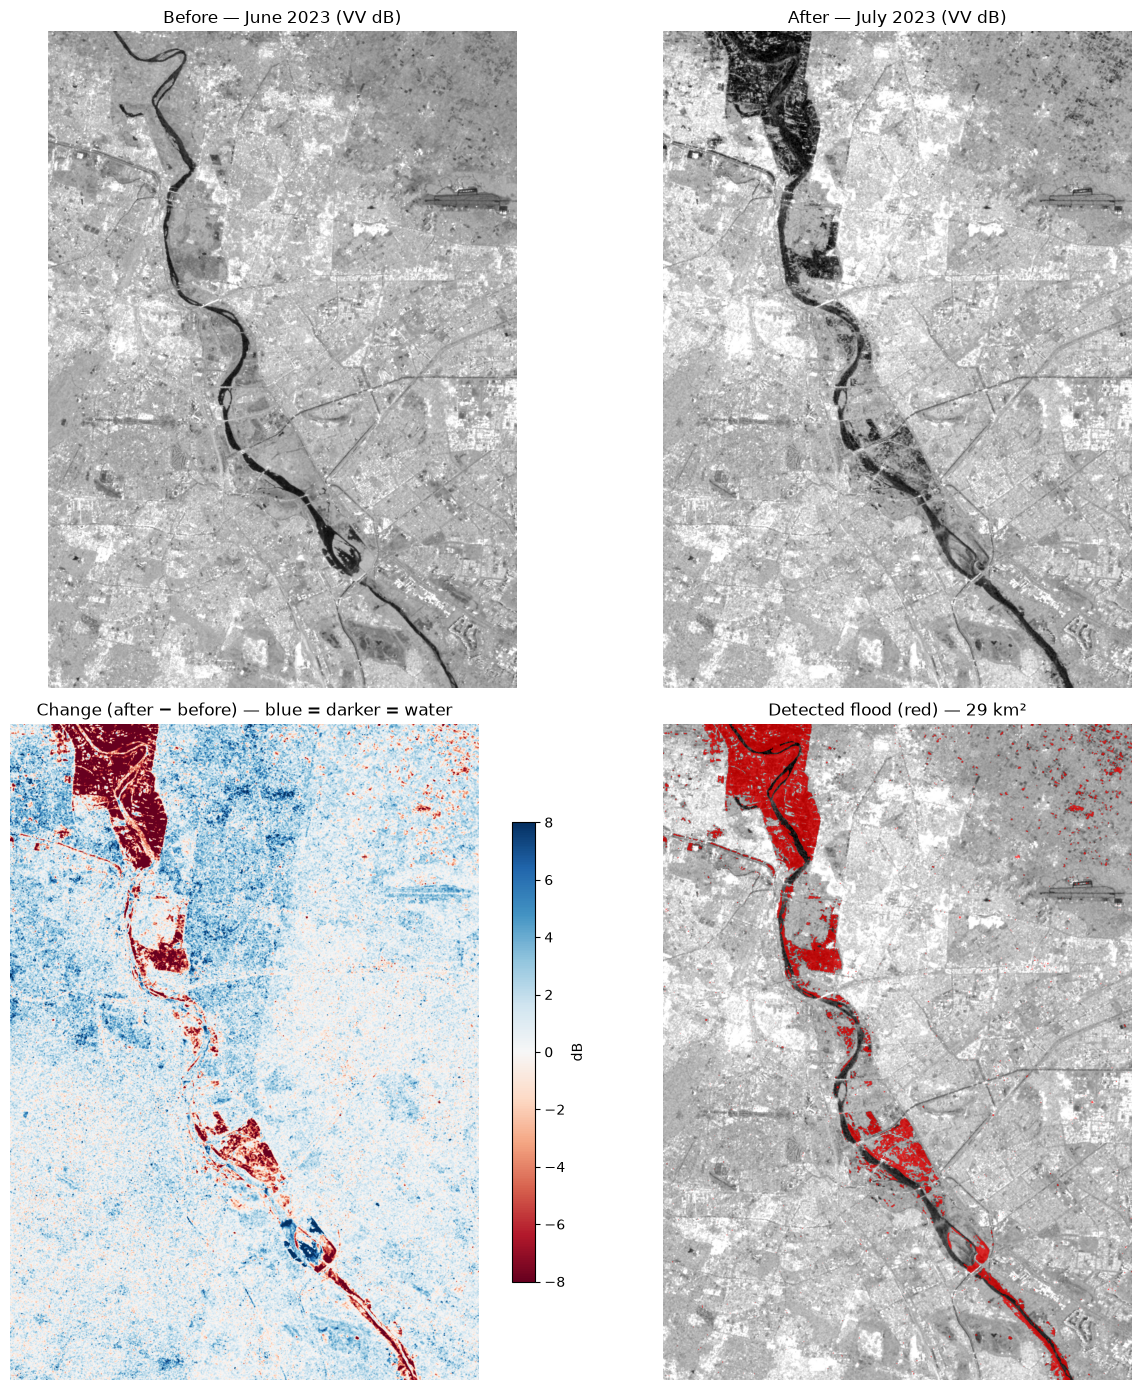

In [8]:
fig, ax = plt.subplots(2, 2, figsize=(13, 14))

ax[0, 0].imshow(pre_f, cmap="gray", vmin=-25, vmax=0)
ax[0, 0].set_title("Before — June 2023 (VV dB)")

ax[0, 1].imshow(post_f, cmap="gray", vmin=-25, vmax=0)
ax[0, 1].set_title("After — July 2023 (VV dB)")

im = ax[1, 0].imshow(diff, cmap="RdBu", vmin=-8, vmax=8)
ax[1, 0].set_title("Change (after − before) — blue = darker = water")
fig.colorbar(im, ax=ax[1, 0], shrink=0.7, label="dB")

ax[1, 1].imshow(post_f, cmap="gray", vmin=-25, vmax=0)
flood_overlay = np.ma.masked_where(~flood, flood)
ax[1, 1].imshow(flood_overlay, cmap="autumn", alpha=0.7)
ax[1, 1].set_title(f"Detected flood (red) — {flood_km2:.0f} km²")

for a in ax.ravel():
    a.axis("off")
plt.tight_layout()
plt.show()

## Recap

You loaded the two radar images, calmed their speckle, subtracted them to find where the ground got darker, thresholded that into a clean flood mask, removed the permanent river channel, and saved `flood_mask.tif`.

**Next — Notebook 3:** bring in the supporting map layers (elevation, the Yamuna river line, roads) that we'll need for the risk map, all lined up to this same grid.